In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# CHARGEMENT

In [2]:
marvel = pd.read_csv("marvel_movies_dataset.csv")
marvel.columns

Index(['movie_id', 'movie_title', 'release_date', 'release_year',
       'mcu_timeline_order', 'phase', 'phase_number', 'director', 'lead_actor',
       'runtime_minutes', 'production_budget_millions',
       'worldwide_box_office_millions', 'domestic_box_office_millions',
       'profit_millions', 'roi_percentage', 'domestic_percentage',
       'imdb_rating', 'rotten_tomatoes', 'metacritic_score', 'storyline'],
      dtype='object')

### Suppression des colonnes que je ne compte pas utilisé (o_o)

In [3]:
marvel = marvel.drop(['metacritic_score', 'rotten_tomatoes', 
                      'storyline', 'movie_id', 'phase', 'mcu_timeline_order',
                      'roi_percentage', 'domestic_percentage', 
                      'worldwide_box_office_millions', 'domestic_box_office_millions', 'release_date'],axis=1)

#### Petite visualisation

In [4]:
marvel.head()

,movie_title,release_year,phase_number,director,lead_actor,runtime_minutes,production_budget_millions,profit_millions,imdb_rating
0,Iron Man,2008,1,Jon Favreau,Robert Downey Jr.,126,140,445,7.9
1,The Incredible Hulk,2008,1,Louis Leterrier,Edward Norton,112,150,114,6.7
2,Iron Man 2,2010,1,Jon Favreau,Robert Downey Jr.,124,200,423,7.0
3,Thor,2011,1,Kenneth Branagh,Chris Hemsworth,115,150,299,7.0
4,Captain America: The First Avenger,2011,1,Joe Johnston,Chris Evans,124,140,230,6.9


# Top 10 des films les mieux notés vs les moins bien notés sur imbd

### Les mieux notés :

In [5]:
top10_first = marvel.sort_values(by="imdb_rating", ascending=False)[["movie_title", "imdb_rating"]].head(10)
print(top10_first)

                            movie_title  imdb_rating
18               Avengers: Infinity War          8.4
21                    Avengers: Endgame          8.4
26              Spider-Man: No Way Home          8.2
5                          The Avengers          8.0
9               Guardians of the Galaxy          8.0
0                              Iron Man          7.9
16                       Thor: Ragnarok          7.9
31       Guardians of the Galaxy Vol. 3          7.9
12           Captain America: Civil War          7.8
8   Captain America: The Winter Soldier          7.7


**Important : Thor: ragnarok a la 7e place c'est un scandale**

### Les moins bien notés :

In [6]:
top10_last = marvel.sort_values(by="imdb_rating", ascending=True)[["movie_title", "imdb_rating"]].head(10)
print(top10_last)

                           movie_title  imdb_rating
32                         The Marvels          5.5
30   Ant-Man and The Wasp: Quantumania          6.1
28              Thor: Love and Thunder          6.2
25                            Eternals          6.3
23                         Black Widow          6.7
1                  The Incredible Hulk          6.7
20                      Captain Marvel          6.8
7                 Thor: The Dark World          6.8
29      Black Panther: Wakanda Forever          6.8
4   Captain America: The First Avenger          6.9


Le film le mieux noté de la franchise est **Avengers: Infinity War a égalité avec Avengers: Endgame**

Le film le moins bien noté quant a lui est **The Marvels** (PS: Compréhensible)

# Evolution des profits par annee (millions $)

In [7]:
evol_box_office = marvel.groupby('release_year')['profit_millions'].sum().sort_values(ascending=False)
print(evol_box_office)

release_year
2019    4390
2018    3333
2021    2279
2017    2041
2022    1874
2015    1544
2013    1488
2016    1415
2012    1298
2014    1144
2024    1038
2023     827
2008     559
2011     529
2010     423
Name: profit_millions, dtype: int64


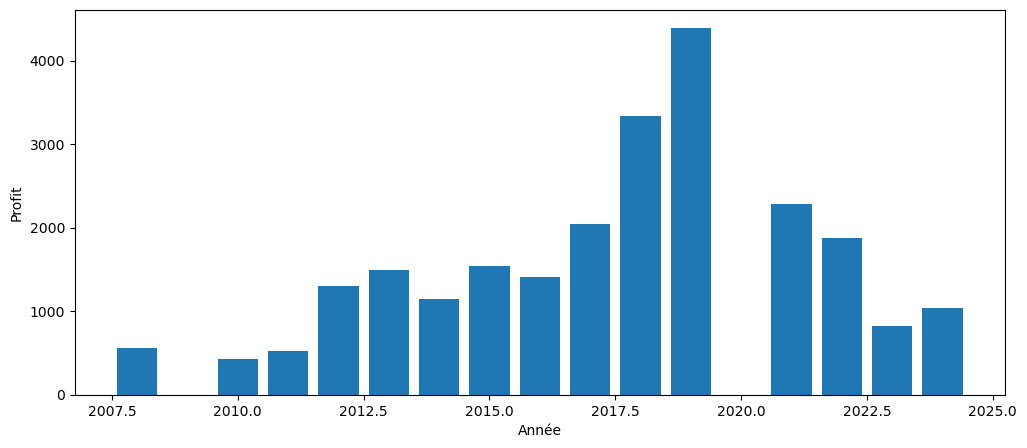

In [8]:
plt.figure(figsize=(12,5))

plt.bar(evol_box_office.index, evol_box_office.values)
plt.xlabel("Année")
plt.ylabel("Profit")
plt.show()

## En savoir plus...

#### Nombre de projets par année

In [9]:
nbre_films_annee = marvel['release_year'].value_counts()
nbre_films_annee

release_year
2021    4
2022    3
2019    3
2018    3
2023    3
2017    3
2008    2
2013    2
2011    2
2014    2
2015    2
2016    2
2010    1
2012    1
2024    1
Name: count, dtype: int64

**L’année 2021 a enregistré le meilleur bénéfice grâce à la sortie de quatre films, un record pour la franchise depuis 2008 (~ approximatif puisque basé sur ce dataset)**

# Evolution des profits par phase (millions $)

In [10]:
comp_phase = marvel.groupby('phase_number')['profit_millions'].sum().sort_values(ascending = False)
comp_phase

phase_number
3    11179
2     4176
4     4153
1     2809
5     1865
Name: profit_millions, dtype: int64

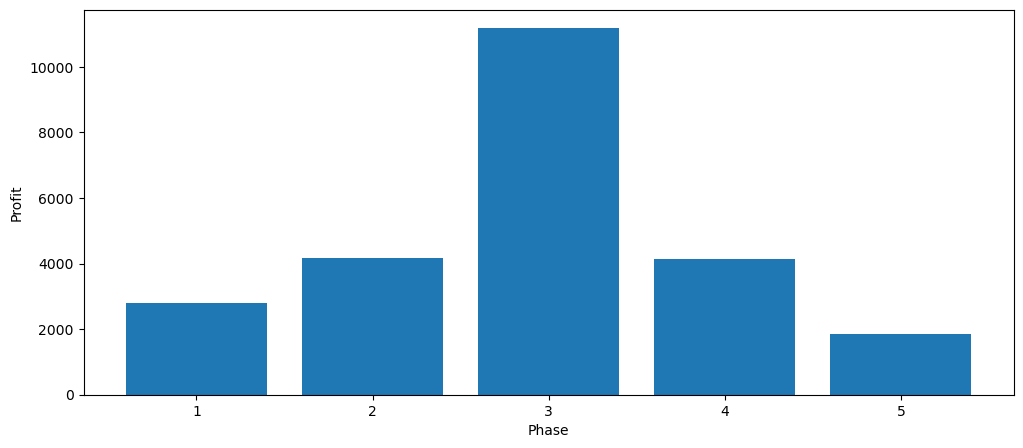

In [11]:
plt.figure(figsize=(12,5))

plt.bar(comp_phase.index, comp_phase.values)
plt.xlabel("Phase")
plt.ylabel("Profit")
plt.show()

**La phase la plus rentable du MCU est la phase 3**

## En savoir plus...

#### Nombre de projets par phase

In [12]:
marvel['phase_number'].value_counts()

phase_number
3    11
4     7
1     6
2     6
5     4
Name: count, dtype: int64

#### Différentes productions de la phase 3

In [13]:
marvel[marvel['phase_number'] == 3]

,movie_title,release_year,phase_number,director,lead_actor,runtime_minutes,production_budget_millions,profit_millions,imdb_rating
12,Captain America: Civil War,2016,3,"Anthony Russo, Joe Russo",Chris Evans,147,250,903,7.8
13,Doctor Strange,2016,3,Scott Derrickson,Benedict Cumberbatch,115,165,512,7.5
14,Guardians of the Galaxy Vol. 2,2017,3,James Gunn,Chris Pratt,136,200,663,7.6
15,Spider-Man: Homecoming,2017,3,Jon Watts,Tom Holland,133,175,705,7.4
16,Thor: Ragnarok,2017,3,Taika Waititi,Chris Hemsworth,130,180,673,7.9
17,Black Panther,2018,3,Ryan Coogler,Chadwick Boseman,134,200,1146,7.3
18,Avengers: Infinity War,2018,3,"Anthony Russo, Joe Russo",Robert Downey Jr.,149,321,1727,8.4
19,Ant-Man and The Wasp,2018,3,Peyton Reed,Paul Rudd,118,162,460,7.0
20,Captain Marvel,2019,3,"Anna Boden, Ryan Fleck",Brie Larson,124,152,976,6.8
21,Avengers: Endgame,2019,3,"Anthony Russo, Joe Russo",Robert Downey Jr.,181,356,2442,8.4


**On constate que le nombre de projets allant a 11 explique cette rentabilité de la phase 3.**

# Evolution de la moyenne de duree des films par année

In [14]:
dur_film_moy = marvel.groupby('release_year')['runtime_minutes'].mean().sort_values(ascending=False)
dur_film_moy

release_year
2019    144.666667
2012    143.000000
2021    142.500000
2022    135.333333
2018    133.666667
2017    133.000000
2016    131.000000
2015    129.000000
2014    129.000000
2024    128.000000
2023    126.333333
2010    124.000000
2013    121.000000
2011    119.500000
2008    119.000000
Name: runtime_minutes, dtype: float64

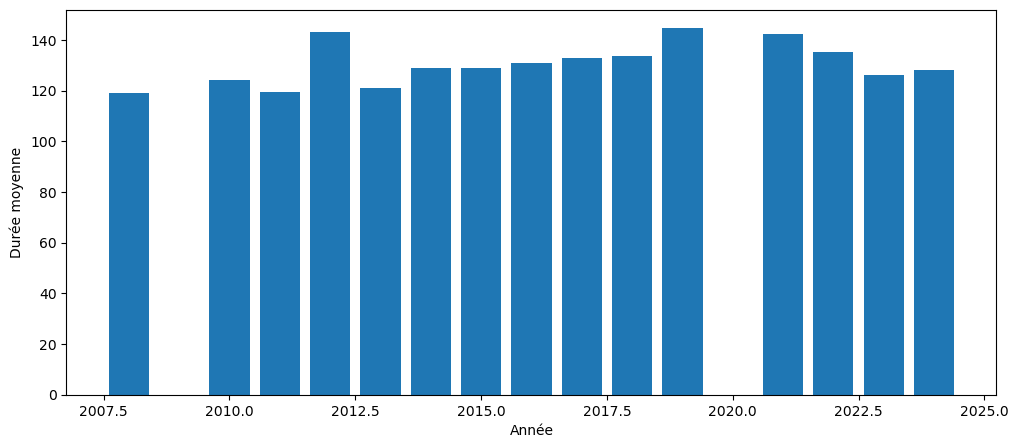

In [15]:
plt.figure(figsize=(12,5))

plt.bar(dur_film_moy.index, dur_film_moy.values)
plt.xlabel("Année")
plt.ylabel("Durée moyenne")
plt.show()

**On ne constate pas un écart si grand dans la moyenne des films depuis 2008, le studio reste surtout dans les alentours de 130 minutes soit 2 h 10 min**

# Acteur le plus presents dans la franchise (lead_actor)

In [16]:
acteur = marvel['lead_actor'].value_counts()
acteur

lead_actor
Robert Downey Jr.       7
Chris Hemsworth         4
Chris Evans             3
Paul Rudd               3
Chris Pratt             3
Tom Holland             3
Benedict Cumberbatch    2
Brie Larson             2
Edward Norton           1
Chadwick Boseman        1
Scarlett Johansson      1
Simu Liu                1
Gemma Chan              1
Letitia Wright          1
Ryan Reynolds           1
Name: count, dtype: int64

### En savoir plus...

#### Différentes apparitions de Downey jr

In [17]:
marvel[marvel['lead_actor'] == 'Robert Downey Jr.']

,movie_title,release_year,phase_number,director,lead_actor,runtime_minutes,production_budget_millions,profit_millions,imdb_rating
0,Iron Man,2008,1,Jon Favreau,Robert Downey Jr.,126,140,445,7.9
2,Iron Man 2,2010,1,Jon Favreau,Robert Downey Jr.,124,200,423,7.0
5,The Avengers,2012,1,Joss Whedon,Robert Downey Jr.,143,220,1298,8.0
6,Iron Man 3,2013,2,Shane Black,Robert Downey Jr.,130,200,1014,7.2
10,Avengers: Age of Ultron,2015,2,Joss Whedon,Robert Downey Jr.,141,250,1155,7.3
18,Avengers: Infinity War,2018,3,"Anthony Russo, Joe Russo",Robert Downey Jr.,149,321,1727,8.4
21,Avengers: Endgame,2019,3,"Anthony Russo, Joe Russo",Robert Downey Jr.,181,356,2442,8.4


**L'acteur qui a eu le plus de lead dans le Marvel Cinematic Universe est Robert Downey Jr.**

# Liste des films a perte

In [18]:
marvel[marvel['production_budget_millions'] > marvel['profit_millions']]

,movie_title,release_year,phase_number,director,lead_actor,runtime_minutes,production_budget_millions,profit_millions,imdb_rating
1,The Incredible Hulk,2008,1,Louis Leterrier,Edward Norton,112,150,114,6.7
23,Black Widow,2021,4,Cate Shortland,Scarlett Johansson,134,200,179,6.7
25,Eternals,2021,4,Chloé Zhao,Gemma Chan,156,236,166,6.3
32,The Marvels,2023,5,Nia DaCosta,Brie Larson,105,250,-44,5.5


**On constate donc que depuis le depuis de la phase 1 seulement 4 productions ont été a perte pour Marvel**